In [ ]:
!pip install Keras-Preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 359.0 kB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
import json
import nltk

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D, Bidirectional, GlobalMaxPool1D, Conv1D
from tensorflow.keras.utils import to_categorical

import plotly as py
import cufflinks as cf
from plotly.offline import iplot
py.offline.init_notebook_mode(connected=True)
cf.go_offline()


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
df=pd.read_csv('/content/15K_Random.csv')

In [ ]:
newdf = df.copy()

In [ ]:
df.head()

,review,sentiment
0,অসাধারণ অস্থির,Positive
1,অস্থির একটা জিনিস,Positive
2,অস্থির একটি প্রোডাক্ট। চোখ বন্ধ করে নিতে পারেন।,Positive
3,অস্থির প্রোডাক্ট। দেখার পালা কতদিন লাস্টিং করে।,Positive
4,"অ‌স্থির ব্রা, যেমন দেখছি ঠিক তেমন",Positive


In [ ]:
df["sentiment"].unique()

array(['Positive', 'Neutral', 'Negative'], dtype=object)

In [ ]:
df.shape

(15034, 2)

In [ ]:
print("Total Comment:",len(df),
      "\nTotal Negative :",len(df[df.sentiment =='Negative']),
      "\nTotal Positive :",len(df[df.sentiment=='Positive']),
      "\nTotal Neutral :",len(df[df.sentiment=='Neutral']))

Total Comment: 15034 
Total Negative : 5066 
Total Positive : 5147 
Total Neutral : 4821


In [ ]:
import os

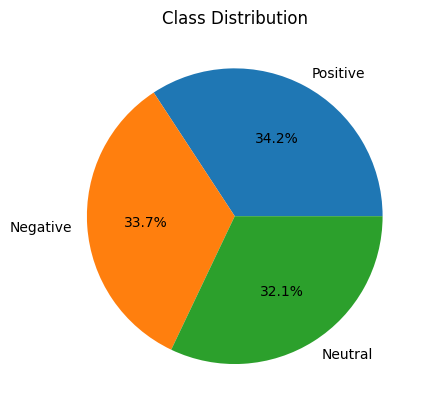

In [ ]:
class_counts = df['sentiment'].value_counts()
class_percents = class_counts / class_counts.sum() * 100
# Plot the pie chart
plt.pie(class_percents, labels=class_counts.index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.savefig("my_plot.png")
plt.show()

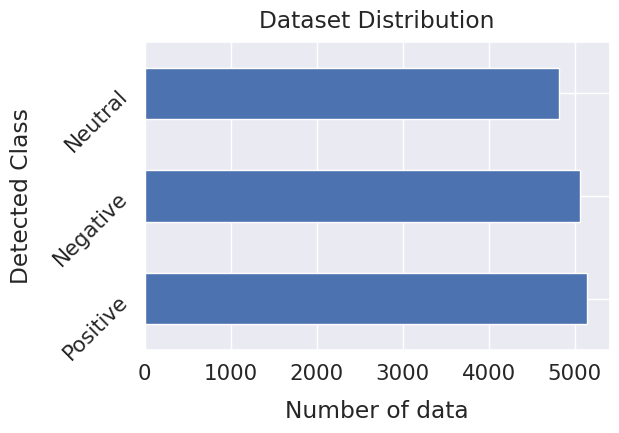

In [ ]:
sns.set(font_scale=1.4)
df['sentiment'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Number of data", labelpad=12)
plt.ylabel("Detected Class", labelpad=12)
plt.yticks(rotation = 45)
plt.title("Dataset Distribution", y=1.02);
plt.savefig("Dataset Distribution BarChart.png")

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


# **Data Preprocessing and Cleaning**

In [ ]:
df.drop_duplicates(inplace=True)

# **Stopwords Remove**

In [ ]:
def process_conversations(Conversation):
    stp = open('/content/stopwords-bn (1)(1).txt','r',encoding="utf8").read().split()
    result = Conversation.split()
    Conversation = [word.strip() for word in result if word not in stp ]
    Conversation =" ".join(Conversation)
    Conversation = re.sub('[^\u0980-\u09FF]',' ',str(Conversation))
    return Conversation

In [ ]:
df.dtypes

,0
review,object
sentiment,object


In [ ]:
df['cleaned'] = df['review'].apply(process_conversations)
sample_data = [10,700]
for i in sample_data:
     print('Original:\n',df.review[i],'\nCleaned:\n',
           df.cleaned[i],'\n','Detected as:-- ',df.sentiment[i],'\n')

Original:
 কিছু বলার নাই।এক কথায়,অল্প টাকায় দূর্দান্ত। 
Cleaned:
 বলার নাই এক কথায় অল্প টাকায় দূর্দান্ত  
 Detected as:--  Positive 

Original:
 সব কিছু ঠিকঠাক ছিল। আর সেলার ভাই এর আচরণ অনেক ভালো ছিল। আর ফাস্ট চার্জ হয় কিন্তু চার্জার কিছুটা গরম হয়। 
Cleaned:
 ঠিকঠাক ছিল  সেলার ভাই আচরণ ভালো ছিল  ফাস্ট চার্জ চার্জার কিছুটা গরম হয়  
 Detected as:--  Positive 



In [ ]:
df

,review,sentiment,cleaned
0,অসাধারণ অস্থির,Positive,অসাধারণ অস্থির
1,অস্থির একটা জিনিস,Positive,অস্থির একটা জিনিস
2,অস্থির একটি প্রোডাক্ট। চোখ বন্ধ করে নিতে পারেন।,Positive,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন
3,অস্থির প্রোডাক্ট। দেখার পালা কতদিন লাস্টিং করে।,Positive,অস্থির প্রোডাক্ট দেখার পালা কতদিন লাস্টিং করে
4,"অ‌স্থির ব্রা, যেমন দেখছি ঠিক তেমন",Positive,অ স্থির ব্রা দেখছি
...,...,...,...
15029,ছবিটা দেখানো প্যাডের সাথে পাঠানো প্যাডের কোন ম...,Negative,ছবিটা দেখানো প্যাডের সাথে পাঠানো প্যাডের মিল নেই
15030,ছবিতে এক রকম মাল পাওয়া যায়,Negative,ছবিতে এক মাল
15031,ছবিতে দেয়া অরিজিনাল ওয়াল্টনের রিমোট কিন্তু দেয়...,Negative,ছবিতে দেয়া অরিজিনাল ওয়াল্টনের রিমোট দেয়া চাইনি...
15032,ছবিতে যেটা আছে সেটা পাইনি,Negative,ছবিতে যেটা পাইনি


# **Small Text Remove**

In [ ]:
df['length'] = df['cleaned'].apply(lambda x:len(x.split()))

dataset = df.loc[df.length>0]
dataset = dataset.reset_index(drop = True)
print("After Cleaning:","\nRemoved {} Small conversations".format(len(df)-len(dataset)),
      "\nTotal conversations:",len(dataset))

dataset['no_char'] = df['cleaned'].apply(lambda cleaned: len(cleaned))

After Cleaning: 
Removed 12 Small conversations 
Total conversations: 15014


In [ ]:
dataset

,review,sentiment,cleaned,length,no_char
0,অসাধারণ অস্থির,Positive,অসাধারণ অস্থির,2,14.0
1,অস্থির একটা জিনিস,Positive,অস্থির একটা জিনিস,3,17.0
2,অস্থির একটি প্রোডাক্ট। চোখ বন্ধ করে নিতে পারেন।,Positive,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন,5,33.0
3,অস্থির প্রোডাক্ট। দেখার পালা কতদিন লাস্টিং করে।,Positive,অস্থির প্রোডাক্ট দেখার পালা কতদিন লাস্টিং করে,7,47.0
4,"অ‌স্থির ব্রা, যেমন দেখছি ঠিক তেমন",Positive,অ স্থির ব্রা দেখছি,4,19.0
...,...,...,...,...,...
15009,ছবিটা দেখানো প্যাডের সাথে পাঠানো প্যাডের কোন ম...,Negative,ছবিটা দেখানো প্যাডের সাথে পাঠানো প্যাডের মিল নেই,8,50.0
15010,ছবিতে এক রকম মাল পাওয়া যায়,Negative,ছবিতে এক মাল,3,86.0
15011,ছবিতে দেয়া অরিজিনাল ওয়াল্টনের রিমোট কিন্তু দেয়...,Negative,ছবিতে দেয়া অরিজিনাল ওয়াল্টনের রিমোট দেয়া চাইনি...,13,34.0
15012,ছবিতে যেটা আছে সেটা পাইনি,Negative,ছবিতে যেটা পাইনি,3,10.0


# **Stemming**

In [ ]:
!pip install bangla-stemmer
from bangla_stemmer.stemmer import stemmer
## stemmer function
def stem_text (x):
  stmr = stemmer.BanglaStemmer()
  words=x.split(' ')
  stm = stmr.stem(words)
  words=(' ').join(stm)
  return words

In [ ]:
dataset.head()

,review,sentiment,cleaned,length,no_char
0,অসাধারণ অস্থির,Positive,অসাধারণ অস্থির,2,14.0
1,অস্থির একটা জিনিস,Positive,অস্থির একটা জিনিস,3,17.0
2,অস্থির একটি প্রোডাক্ট। চোখ বন্ধ করে নিতে পারেন।,Positive,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন,5,33.0
3,অস্থির প্রোডাক্ট। দেখার পালা কতদিন লাস্টিং করে।,Positive,অস্থির প্রোডাক্ট দেখার পালা কতদিন লাস্টিং করে,7,47.0
4,"অ‌স্থির ব্রা, যেমন দেখছি ঠিক তেমন",Positive,অ স্থির ব্রা দেখছি,4,19.0


In [ ]:
dataset['stemming']=dataset['cleaned'].apply(stem_text)

Streaming output truncated to the last 5000 lines.
applied second rules..
applied fourth rules..
applied first rules..
applied second rules..
applied second rules..
applied first rules..
applied first rules..
applied first rules..
applied first rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied first rules..
applied first rules..
applied fourth rules..
applied first rules..
applied first rules..
applied fourth rules..
applied first rules..
applied second rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied second rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied fourth rules..
applied fourth rules..
applied first rules..
applied fourth rules..
applied first rules..
applied second rules..
applied fourth rules..
applied first rules..
applied second rules..
applied fourth rules..
applied fourth rules..

In [ ]:
dataset

,review,sentiment,cleaned,length,no_char,stemming
0,অসাধারণ অস্থির,Positive,অসাধারণ অস্থির,2,14.0,অসাধারণ অস্থির
1,অস্থির একটা জিনিস,Positive,অস্থির একটা জিনিস,3,17.0,অস্থির এক জিন
2,অস্থির একটি প্রোডাক্ট। চোখ বন্ধ করে নিতে পারেন।,Positive,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন,5,33.0,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন
3,অস্থির প্রোডাক্ট। দেখার পালা কতদিন লাস্টিং করে।,Positive,অস্থির প্রোডাক্ট দেখার পালা কতদিন লাস্টিং করে,7,47.0,অস্থির প্রোডাক্ট দেখ পালা কতদিন লাস্টিং করে
4,"অ‌স্থির ব্রা, যেমন দেখছি ঠিক তেমন",Positive,অ স্থির ব্রা দেখছি,4,19.0,অ স্থির ব্ দেখ
...,...,...,...,...,...,...
15009,ছবিটা দেখানো প্যাডের সাথে পাঠানো প্যাডের কোন ম...,Negative,ছবিটা দেখানো প্যাডের সাথে পাঠানো প্যাডের মিল নেই,8,50.0,ছবি দেখানো প্যাড সাথে পাঠানো প্যাড মিল নেই
15010,ছবিতে এক রকম মাল পাওয়া যায়,Negative,ছবিতে এক মাল,3,86.0,ছবি এক মাল
15011,ছবিতে দেয়া অরিজিনাল ওয়াল্টনের রিমোট কিন্তু দেয়...,Negative,ছবিতে দেয়া অরিজিনাল ওয়াল্টনের রিমোট দেয়া চাইনি...,13,34.0,ছবি দেয়া অরিজিনাল ওয়াল্টন রিমোট দেয়া চাইনিজ ডু...
15012,ছবিতে যেটা আছে সেটা পাইনি,Negative,ছবিতে যেটা পাইনি,3,10.0,ছবি যেটা পাইনি


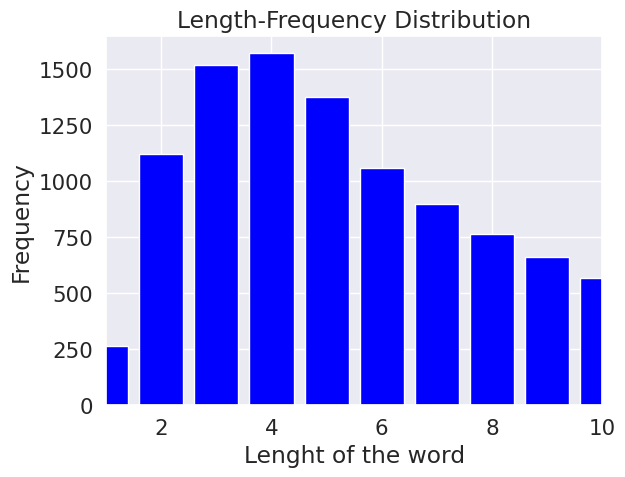

Maximum Length of a comment: 139
Minimum Length of a comment: 1
Average Length of a comment: 10.0


In [ ]:
frequency = dict()
for i in dataset.length:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="blue")
plt.xlim(1, 10)

plt.xlabel('Lenght of the word')
plt.ylabel('Frequency')
plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a comment: {max(dataset.length)}")
print(f"Minimum Length of a comment: {min(dataset.length)}")
print(f"Average Length of a comment: {round(np.mean(dataset.length),0)}")

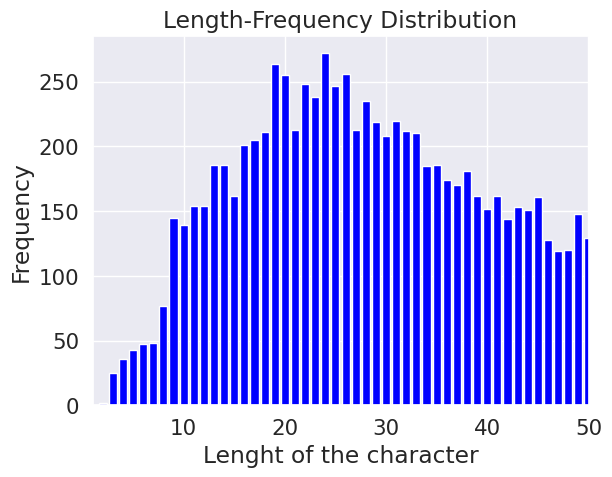

Maximum Length of a comment: 833.0
Minimum Length of a comment: 0.0
Average Length of a comment: 66.0


<Figure size 640x480 with 0 Axes>

In [ ]:
frequency = dict()
for i in dataset.no_char:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="blue")
plt.xlim(1, 50)

plt.xlabel('Lenght of the character')
plt.ylabel('Frequency')
plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a comment: {max(dataset.no_char)}")
print(f"Minimum Length of a comment: {min(dataset.no_char)}")
print(f"Average Length of a comment: {round(np.mean(dataset.no_char),0)}")
plt.savefig("Character Frequency Distribution Bangla BarChart.png")

# **Dataset Summary**

In [ ]:
def data_summary(dataset):
    documents = []
    words = []
    most_frequent_word =[]
    u_words = []

    total_u_words = [word.strip().lower() for t in list(dataset.cleaned) for word in t.strip().split()]
    class_label= [k for k,v in dataset.sentiment.value_counts().to_dict().items()]

    for label in class_label:
        word_list = [word.strip().lower() for t in list(dataset[dataset.sentiment==label].cleaned) for word in t.strip().split()]

        counts = dict()

        for word in word_list:
                counts[word] = counts.get(word, 0)+1

        ordered = sorted(counts.items(), key= lambda item: item[1],reverse = True)

        documents.append(len(list(dataset[dataset.sentiment==label].cleaned)))

        words.append(len(word_list))

        u_words.append(len(np.unique(word_list)))

        print("\nClass Name : ",label)
        print("Number of comments:{}".format(len(list(dataset[dataset.sentiment==label].cleaned))))
        print("Number of Words:{}".format(len(word_list)))
        print("Number of Unique Words:{}".format(len(np.unique(word_list))))
        print("Most Frequent Words:\n")
        for k,v in ordered[:15]:
              print("{}\t{}".format(k,v))
    print("Total Number of Unique Words:{}".format(len(np.unique(total_u_words))))

    return documents,words,u_words,class_label

documents,words,u_words,class_names = data_summary(dataset)


Class Name :  Positive
Number of comments:5144
Number of Words:63250
Number of Unique Words:7049
Most Frequent Words:

ভালো	4328
ধন্যবাদ	2214
আলহামদুলিল্লাহ	1508
সুন্দর	1292
প্রোডাক্ট	1176
সেলার	993
ডেলিভারি	803
পেয়েছি	802
দারাজ	779
পেয়েছি	709
পারেন	658
আপনারা	642
চাইলে	626
একটা	619
টা	576

Class Name :  Negative
Number of comments:5055
Number of Words:53555
Number of Unique Words:8775
Most Frequent Words:

না	1034
একটা	973
বাজে	954
ভালো	946
অর্ডার	709
প্রোডাক্ট	586
টা	566
কালার	491
টাকা	482
খারাপ	476
একদম	409
দিছে	367
জিনিস	364
সাথে	363
খুবই	362

Class Name :  Neutral
Number of comments:4815
Number of Words:38149
Number of Unique Words:7126
Most Frequent Words:

ভালো	1794
মোটামুটি	874
দাম	553
একটু	464
না	433
কিছুটা	299
কম	292
খারাপ	290
টা	287
প্রোডাক্ট	247
ভালোই	230
একটা	227
ছোট	225
ডেলিভারি	217
মান	199
Total Number of Unique Words:15500


In [ ]:
data_matrix = pd.DataFrame({'Total comments':documents,
                            'Total Words':words,
                            'Unique Words':u_words,
                            'Class Names':class_names})
data = pd.melt(data_matrix, id_vars="Class Names", var_name="Category", value_name="Values")

In [ ]:
data

,Class Names,Category,Values
0,Positive,Total comments,5144
1,Negative,Total comments,5055
2,Neutral,Total comments,4815
3,Positive,Total Words,63250
4,Negative,Total Words,53555
5,Neutral,Total Words,38149
6,Positive,Unique Words,7049
7,Negative,Unique Words,8775
8,Neutral,Unique Words,7126


# **Data Summary Visualization**

/tmp/ipython-input-1337874303.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



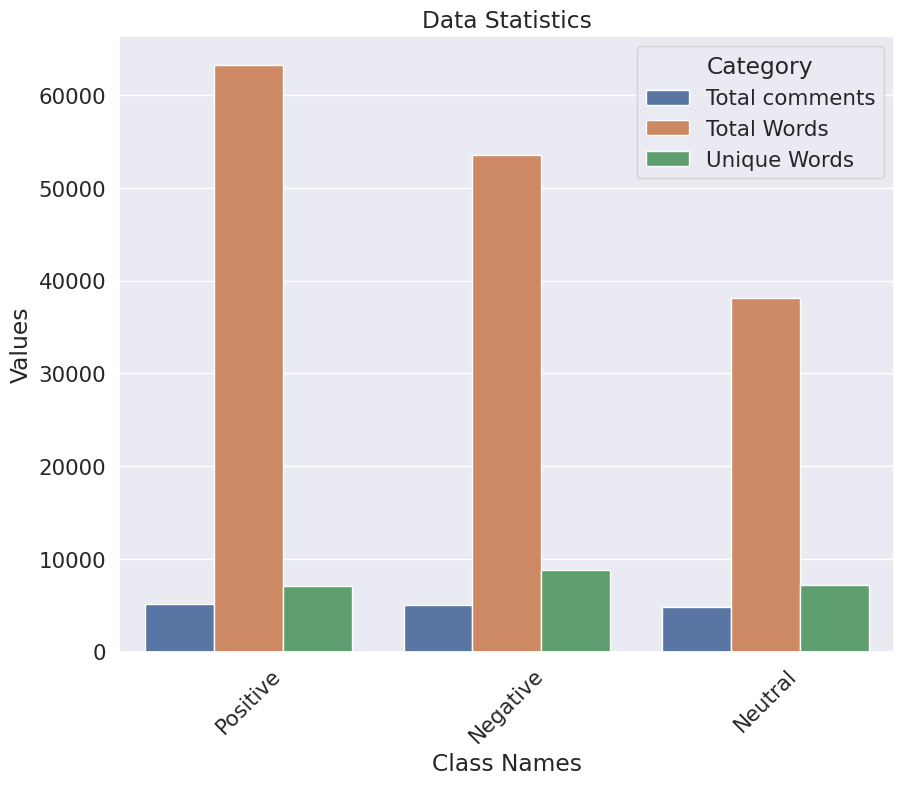

In [ ]:
plt.figure(figsize=(10, 8))
ax = plt.subplot()

sns.barplot(data=data,x='Class Names', y='Values' ,hue='Category')
ax.set_xlabel('Class Names')
ax.set_title('Data Statistics')

ax.xaxis.set_ticklabels(class_names, rotation=45);

plt.savefig("Data Statistics Bangla BarChart.png")

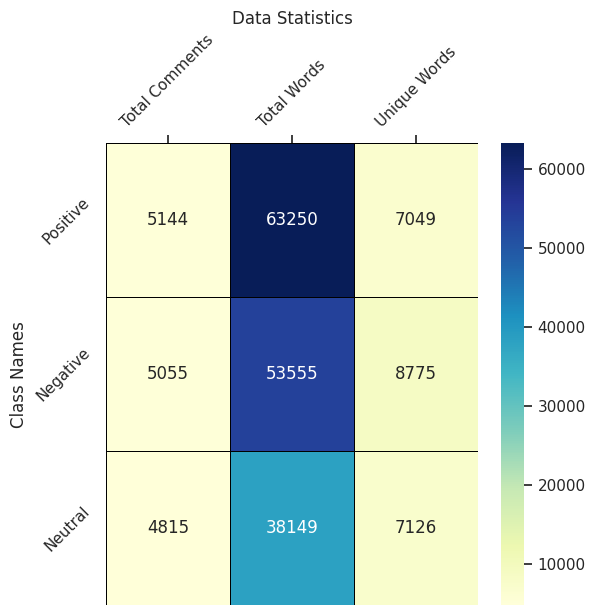

In [ ]:
sns.set()
plt.figure(figsize =(6, 6))
ax = plt.subplot()
sns.heatmap(data_matrix.iloc[:,0:3], annot=True,fmt="d", linewidths=0.5,linecolor = 'Black',cmap = "YlGnBu",ax = ax)

ax.set_ylabel('Class Names')
ax.set_title('Data Statistics')
y_label = ["Total Comments", "Total Words", "Unique Words"]
ax.xaxis.set_ticklabels(y_label, rotation=45); ax.yaxis.set_ticklabels(class_names, rotation=45);
ax.xaxis.tick_top()
plt.savefig("Data Statistics Bangla.png")

# **Data Encoding Function**

In [ ]:
def label_encoding(sentiment,bool):

    le = LabelEncoder()
    le.fit(sentiment)
    encoded_labels = le.transform(sentiment)
    labels = np.array(encoded_labels)
    class_names =le.classes_
    if bool == True:
        print("\n\t\t\t===== Label Encoding =====","\nClass Names:-->",le.classes_)
        for i in sample_data:
            print(sentiment[i],' ', encoded_labels[i],'\n')

    return labels

# **Data Splitting Function**

In [ ]:
def dataset_split(feature_space,sentiment):

    X_train,X_test,y_train,y_test = train_test_split(feature_space,sentiment,train_size = 0.8,
                                                  test_size = 0.2,random_state =0)
    print("Feature Size :======>",X_train.shape[1])
    print("\nDataset Distribution:\n")
    print("\tSet Name","\t\tSize")
    print("\t========\t\t======")

    print("\tFull\t\t\t",feature_space.shape[0],
        "\n\tTraining\t\t",X_train.shape[0],
        "\n\tTest\t\t\t",X_test.shape[0])

    return X_train,X_test,y_train,y_test

In [ ]:
dataset.cleaned = dataset.stemming.apply(lambda x:x.replace('\n',' '))

In [ ]:
dataset

,review,sentiment,cleaned,length,no_char,stemming
0,অসাধারণ অস্থির,Positive,অসাধারণ অস্থির,2,14.0,অসাধারণ অস্থির
1,অস্থির একটা জিনিস,Positive,অস্থির এক জিন,3,17.0,অস্থির এক জিন
2,অস্থির একটি প্রোডাক্ট। চোখ বন্ধ করে নিতে পারেন।,Positive,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন,5,33.0,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন
3,অস্থির প্রোডাক্ট। দেখার পালা কতদিন লাস্টিং করে।,Positive,অস্থির প্রোডাক্ট দেখ পালা কতদিন লাস্টিং করে,7,47.0,অস্থির প্রোডাক্ট দেখ পালা কতদিন লাস্টিং করে
4,"অ‌স্থির ব্রা, যেমন দেখছি ঠিক তেমন",Positive,অ স্থির ব্ দেখ,4,19.0,অ স্থির ব্ দেখ
...,...,...,...,...,...,...
15009,ছবিটা দেখানো প্যাডের সাথে পাঠানো প্যাডের কোন ম...,Negative,ছবি দেখানো প্যাড সাথে পাঠানো প্যাড মিল নেই,8,50.0,ছবি দেখানো প্যাড সাথে পাঠানো প্যাড মিল নেই
15010,ছবিতে এক রকম মাল পাওয়া যায়,Negative,ছবি এক মাল,3,86.0,ছবি এক মাল
15011,ছবিতে দেয়া অরিজিনাল ওয়াল্টনের রিমোট কিন্তু দেয়...,Negative,ছবি দেয়া অরিজিনাল ওয়াল্টন রিমোট দেয়া চাইনিজ ডু...,13,34.0,ছবি দেয়া অরিজিনাল ওয়াল্টন রিমোট দেয়া চাইনিজ ডু...
15012,ছবিতে যেটা আছে সেটা পাইনি,Negative,ছবি যেটা পাইনি,3,10.0,ছবি যেটা পাইনি


In [ ]:
dataset=dataset.drop(["review","cleaned","length","no_char"],axis=1)

In [ ]:
dataset.head()

,sentiment,stemming
0,Positive,অসাধারণ অস্থির
1,Positive,অস্থির এক জিন
2,Positive,অস্থির প্রোডাক্ট চোখ বন্ধ পারেন
3,Positive,অস্থির প্রোডাক্ট দেখ পালা কতদিন লাস্টিং করে
4,Positive,অ স্থির ব্ দেখ


# **Unigram Tf-idf value calculation**

In [ ]:
def calc_gram_tfidf(Conversations):
    tfidf = TfidfVectorizer(ngram_range=(1,3),use_idf=True,tokenizer=lambda x: x.split())
    X = tfidf.fit_transform(Conversations)

    return tfidf,X

# **Unigram**

In [ ]:
x = ["ঠিকঠাক ছিল  সেলার ভাই আচরণ ভালো ছিল  ফাস্ট চার্জ চার্জার কিছুটা গরম হয়"]

def get_top_n_words(x, n):
    vec = CountVectorizer().fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]

get_top_n_words(x,3)

[('কঠ', np.int64(1)), ('আচরণ', np.int64(1)), ('গরম', np.int64(1))]

# **Bigram**

In [ ]:
y = ["ঠিকঠাক ছিল  সেলার ভাই আচরণ ভালো ছিল  ফাস্ট চার্জ চার্জার কিছুটা গরম হয়"]
def get_top_n_words(x, n):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]
get_top_n_words(y,3)

[('কঠ আচরণ', np.int64(1)), ('আচরণ গরম', np.int64(1)), ('গরম হয', np.int64(1))]

# **Trigram**

In [ ]:
z = ["ঠিকঠাক ছিল  সেলার ভাই আচরণ ভালো ছিল  ফাস্ট চার্জ চার্জার কিছুটা গরম হয়"]
def get_top_n_words(x, n):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]
get_top_n_words(z,3)

[('কঠ আচরণ গরম', np.int64(1)), ('আচরণ গরম হয', np.int64(1))]

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# **Tokenization**

In [ ]:
max_features = 2500
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(dataset['stemming'].values)
X = tokenizer.texts_to_sequences(dataset['stemming'].values)
X = pad_sequences(X)

In [ ]:
X

array([[   0,    0,    0, ...,    0,   71,  464],
       [   0,    0,    0, ...,  464,    4,   27],
       [   0,    0,    0, ...,  377,  194,   29],
       ...,
       [   0,    0,    0, ...,  465,   20,    7],
       [   0,    0,    0, ...,   49,   83,  156],
       [   0,    0,    0, ...,  620, 1766,  678]], dtype=int32)

In [ ]:
np.shape(X)

(15014, 117)

# **Model Implementation**

In [ ]:
X.shape

(15014, 117)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional, Dropout

embed_dim = 64
model = Sequential()
model.add(Embedding(input_dim=max_features, output_dim=embed_dim, input_length=X.shape[1]))
model.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=False)))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, X.shape[1]))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 117, 64)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,843 (1015.01 KB)

 Trainable params: 259,843 (1015.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Y = pd.get_dummies(dataset['sentiment']).values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2,random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(12011, 117) (12011, 3)
(3003, 117) (3003, 3)


In [ ]:
history=model.fit(X_train, Y_train, epochs = 50, batch_size=32, verbose = 1,validation_data=(X_test,Y_test))

Epoch 1/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 81s 198ms/step - accuracy: 0.6033 - loss: 0.8175 - val_accuracy: 0.8265 - val_loss: 0.4285
Epoch 2/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 70s 168ms/step - accuracy: 0.8605 - loss: 0.3892 - val_accuracy: 0.8408 - val_loss: 0.4012
Epoch 3/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 83s 172ms/step - accuracy: 0.8762 - loss: 0.3261 - val_accuracy: 0.8495 - val_loss: 0.3922
Epoch 4/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 85s 180ms/step - accuracy: 0.8889 - loss: 0.2998 - val_accuracy: 0.8478 - val_loss: 0.4271
Epoch 5/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 79s 171ms/step - accuracy: 0.9064 - loss: 0.2555 - val_accuracy: 0.8465 - val_loss: 0.4315
Epoch 6/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 79s 163ms/step - accuracy: 0.9167 - loss: 0.2248 - val_accuracy: 0.8412 - val_loss: 0.4513
Epoch 7/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 83s 164ms/step - accuracy: 0.9236 - loss: 0.2071 - val_accuracy: 0.8425 - val_loss: 0.4882
Epoch 8/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 60s 160ms/step - accuracy: 0.9282 - loss: 0

In [ ]:
import tensorflow as tf

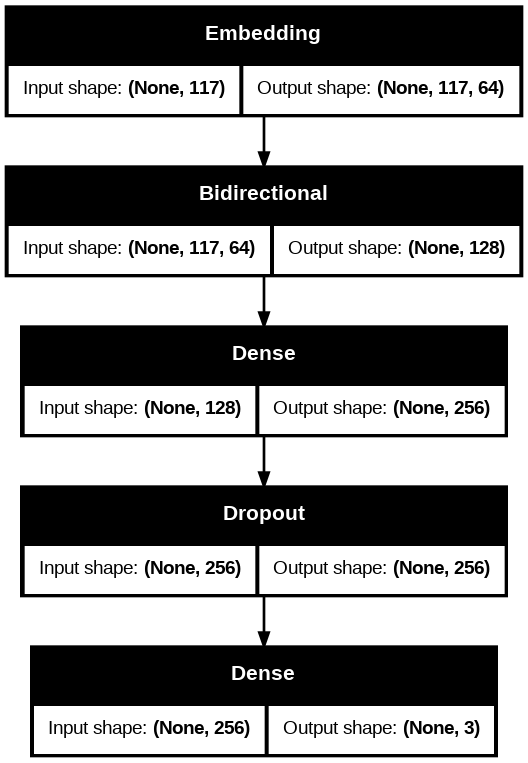

In [ ]:
from tensorflow.keras.utils import plot_model

# Save the model architecture plot
plot_model(
    model,
    to_file='model_architecture3.png',  # ✅ Specify output file
    show_shapes=True,
    dpi=96  # Adjust resolution
)

# **Evaluation**

In [ ]:
score = model.evaluate(X_train, Y_train,batch_size=64, verbose=2)
print('Train loss:', score[0])
print('Train accuracy:', score[1])

188/188 - 6s - 34ms/step - accuracy: 0.9882 - loss: 0.0286
Train loss: 0.028610464185476303
Train accuracy: 0.988177478313446


In [ ]:
score = model.evaluate(X_test, Y_test,batch_size=64, verbose=2)
print('Test loss:', score[0])
acc=score[1]
print('Test accuracy:', acc)

47/47 - 2s - 33ms/step - accuracy: 0.8288 - loss: 1.7326
Test loss: 1.732553243637085
Test accuracy: 0.8288378119468689


# **Learning Curve**

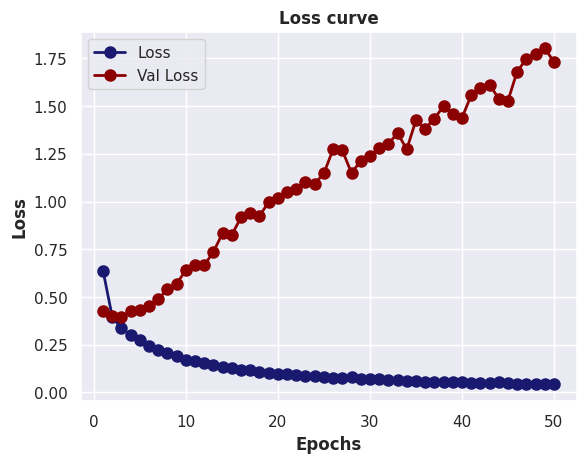

In [ ]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)
sns.set_style('darkgrid')


plt.plot(epochs, loss_values, color='midnightblue', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.plot(epochs, val_loss_values, color='darkred', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.title('Loss curve',fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=12,fontweight='bold')
plt.ylabel('Loss',fontsize=12,fontweight='bold')
plt.legend(['Loss','Val Loss'])

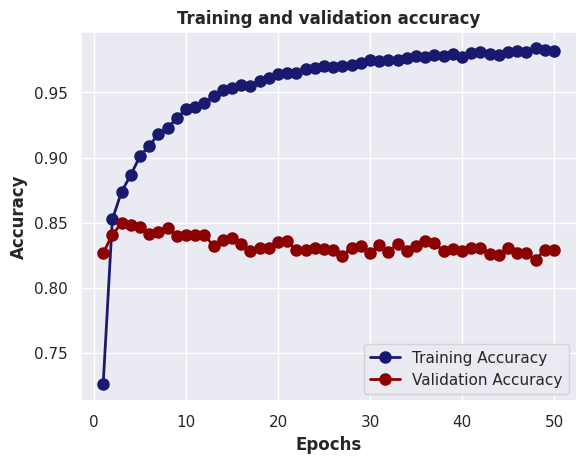

In [ ]:
plt.plot(epochs, acc, color='midnightblue', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.plot(epochs, val_acc, color='darkred', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.title('Training and validation accuracy',fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=12,fontweight='bold')
plt.ylabel('Accuracy',fontsize=12,fontweight='bold')
plt.legend(['Training Accuracy','Validation Accuracy'])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


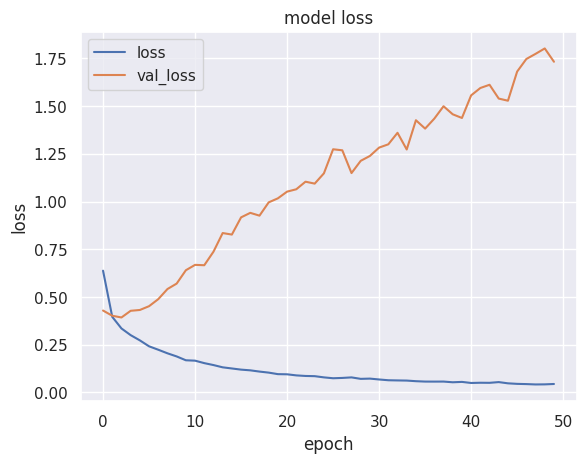

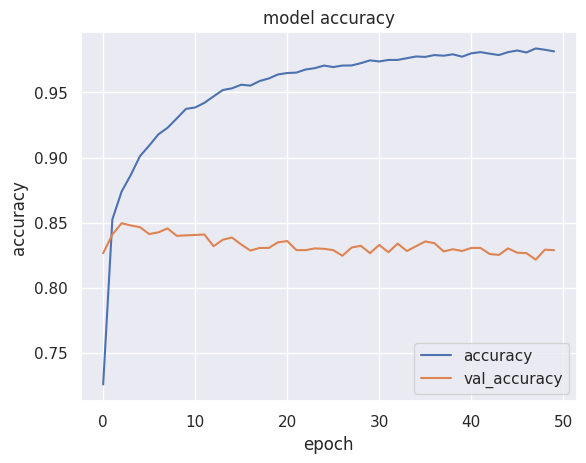

In [ ]:
print(history.history.keys())
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(loss)
plt.plot(val_loss)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'])
plt.show()

accuracy = history.history['accuracy']
val_accuracy= history.history['val_accuracy']
plt.plot(accuracy)
plt.plot(val_accuracy)
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

# **Confusion Matrix & Classification Report**

In [ ]:
X_train.shape,Y_train.shape,X_test.shape,Y_test.shape

((12011, 117), (12011, 3), (3003, 117), (3003, 3))

In [ ]:
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred, axis=1)
y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(y_test, y_pred)
print(cm)

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
[[826 118  55]
 [137 731  81]
 [ 41  82 932]]


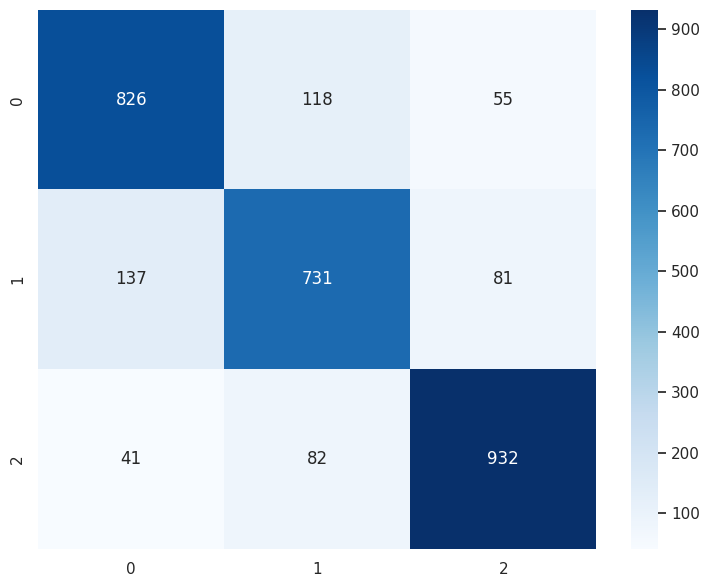

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm,cmap='Blues', annot=True,fmt='d')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
report = pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).transpose()

In [ ]:
report = report.rename(index={'0': 'Positive','1':'Negative','2':'Neutral'})
report[['precision','recall','f1-score']]=report[['precision','recall','f1-score']].apply(lambda x: round(x*100,2))

In [ ]:
report

,precision,recall,f1-score,support
Positive,82.27,82.68,82.48,999.000000
Negative,78.52,77.03,77.77,949.000000
Neutral,87.27,88.34,87.80,1055.000000
accuracy,82.88,82.88,82.88,0.828838
macro avg,82.68,82.68,82.68,3003.000000
weighted avg,82.84,82.88,82.86,3003.000000


# **Output Analysing**

In [ ]:
twt = ['ছবিতে যেটা আছে সেটা পাইনি']
twt = tokenizer.texts_to_sequences(twt)
twt = pad_sequences(twt, maxlen=28, dtype='int32', value=0)
print(twt)
sentiment = model.predict(twt,batch_size=1,verbose = 2)[0]
if(np.argmax(sentiment) == 0):
    print("negative")
elif (np.argmax(sentiment) == 1):
    print("Positive")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0  83 657 156]]
1/1 - 1s - 563ms/step
negative
